</br>
<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555; padding-bottom: 15px; margin-bottom: -8px;">
    <div style="width: 50%;">
        <h2>
            <span style="color: #B30033;">▍</span>CARDIS
        </h2>
        <h1 style="margin-top: -10px;">
            Análisis exploratorio de datos
        </h1>
        </h1>
    </div>
</div>

### Índice:

1) Estadísticos descriptivos e interpretación clínica
2) Distribución del target y desbalanceo
3) Valores ausentes: análisis y estrategia
4) Valores atípicos e inconsistencias
5) Correlaciones y relaciones
6) Variables de texto libre y categóricas de alta cardinalidad
7) Análisis de sesgos poblaciones y equidad
8) Conclusiones y estrategia propuesta

<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 0. Carga de librerías y del conjunto de datos

Este cuaderno está dedicado al análisis exploratorio de datos del conjunto de datos que se utilizará el sistema CARDIS, donde se analizarán diferentes aspectos de estos datos, de acuerdo con el índice previamente mostrado.

En primer lugar, se comenzará por la carga de librerías a utilizar, y del propio conjunto de datos.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuración
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Para reproducibilidad
np.random.seed(42)


cardis_df_train = pd.read_csv(Path("../../data/raw/cardio_risk_train.csv"))
cardis_df_test = pd.read_csv(Path("../../data/raw/cardio_risk_test.csv"))

También se realizará una inspección inicial de los datos.

In [2]:
print(f"Datos de entrenamiento: {cardis_df_train.shape}")
print(f"Datos de test: {cardis_df_test.shape}")

Datos de entrenamiento: (24000, 21)
Datos de test: (16000, 20)


In [3]:
print("=== PRIMERAS 5 FILAS ===")
cardis_df_train.head()

=== PRIMERAS 5 FILAS ===


,id,fecha_visita,edad,altura_cm,peso_kg,imc,presion_sistolica_1,presion_sistolica_2,presion_sistolica_3,colesterol_total,hdl,ldl,glucosa_ayunas,fumador,actividad_fisica,antecedentes_familiares,codigo_postal,hospital_origen,notas_medicas,talla_zapato,riesgo_cv
0,3111,2018-08-07 17:59:44.789084,55,180,86.6,26.6,138.0,208.6,113.6,618.4,46.7,137.4,NaN,0.0,~0.4 horas,0,41015,HOSP-011,El paciente tiene periodos de actividad seguid...,46,0
1,18679,2022-08-02 06:32:46.789084,37,154,45.2,19.0,104.8,115.0,109.5,158.3,54.9,80.7,NaN,0.0,~2.6 horas,1,8031,HOSP-019,"EXPLORACIÓN FÍSICA COMPLETAMENTE NORMAL, SIN N...",41,0
2,17472,2022-04-10 03:55:25.789084,38,164,48.9,18.1,105.5,107.4,123.7,175.9,46.5,110.0,NaN,0.0,~3.7 horas,0,7600,HOSP-008,No se añaden nuevos diagnósticos al historial ...,34,0
3,21451,2020-04-06 05:10:09.789084,75,169,75.9,26.5,129.2,147.1,129.6,186.1,36.3,133.6,96.0,1.0,poco,0,28901,HOSP-016,paciente con alta probabilidad de padecer sínd...,44,1
4,20800,2019-08-22 22:21:21.789084,80,161,89.8,34.7,137.1,135.2,133.8,216.8,41.6,154.8,96.1,0.0,~0.0 horas,1,8907,HOSP-006,Antecedentes Familiares De Infarto De Miocardi...,39,1


In [4]:
cardis_df_train.describe()

,id,edad,altura_cm,peso_kg,imc,presion_sistolica_1,presion_sistolica_2,presion_sistolica_3,colesterol_total,hdl,ldl,glucosa_ayunas,fumador,antecedentes_familiares,codigo_postal,talla_zapato,riesgo_cv
count,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,13606.000000,21782.000000,24000.000000,24000.000000,24000.000000,24000.000000
mean,11999.500000,56.910917,167.686875,69.713275,24.516100,125.952754,125.992633,126.078767,190.673213,42.632292,127.629658,95.701088,0.237581,0.242875,25343.164875,39.063125,0.219000
std,6928.347566,15.857098,9.203348,13.735978,3.718511,13.968335,14.185470,14.460630,59.118220,7.259572,23.721961,10.565080,0.425611,0.428829,13750.949252,3.210177,0.413577
min,0.000000,30.000000,135.000000,41.200000,13.200000,86.500000,84.000000,84.700000,89.100000,28.100000,24.600000,57.700000,0.000000,0.000000,2001.000000,34.000000,0.000000
25%,5999.750000,43.000000,161.000000,60.100000,22.000000,117.000000,117.100000,117.100000,170.700000,36.400000,111.700000,88.500000,0.000000,0.000000,11011.000000,36.000000,0.000000
50%,11999.500000,57.000000,167.000000,69.500000,24.500000,125.500000,125.600000,125.500000,185.400000,42.600000,127.400000,95.700000,0.000000,0.000000,28707.000000,39.000000,0.000000
75%,17999.250000,71.000000,174.000000,79.125000,27.100000,134.000000,134.000000,134.100000,200.400000,48.900000,143.600000,102.900000,0.000000,0.000000,35218.000000,41.000000,0.000000
max,23999.000000,84.000000,201.000000,124.800000,40.500000,296.600000,299.400000,299.200000,999.800000,57.100000,230.500000,134.100000,1.000000,1.000000,50820.000000,46.000000,1.000000


In [5]:
print("=== INFORMACIÓN GENERAL ===")
cardis_df_train.info()

=== INFORMACIÓN GENERAL ===
<class 'pandas.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       24000 non-null  int64  
 1   fecha_visita             24000 non-null  str    
 2   edad                     24000 non-null  int64  
 3   altura_cm                24000 non-null  int64  
 4   peso_kg                  24000 non-null  float64
 5   imc                      24000 non-null  float64
 6   presion_sistolica_1      24000 non-null  float64
 7   presion_sistolica_2      24000 non-null  float64
 8   presion_sistolica_3      24000 non-null  float64
 9   colesterol_total         24000 non-null  float64
 10  hdl                      24000 non-null  float64
 11  ldl                      24000 non-null  float64
 12  glucosa_ayunas           13606 non-null  float64
 13  fumador                  21782 non-null  float64
 14  activ

Como podemos ver, existen valores nulos, que deberemos categorizar y tratar en un futuro.

In [6]:
print("=== TIPOS DE DATOS ===")
print(cardis_df_train.dtypes.value_counts())
print(f"\nTotal de columnas: {len(cardis_df_train.columns)}")

=== TIPOS DE DATOS ===
float64    10
int64       7
str         4
Name: count, dtype: int64

Total de columnas: 21


<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 1. Estadísticos descriptivos e interpretación clínica

Una vez hemos cargado el conjunto de datos, podemos comenzar con un primer análisis más extenso de este, analizando sus estadísticos descriptivos y aportando una interpretación clínica a ellos. Pero antes de ellos, es importante clasificar las diferentes variables de las que se dispone de acuerdo a su tipo, para poder analizarlas como corresponde.

In [7]:
# Clasificar variables por tipo
print("=== CLASIFICACIÓN DE VARIABLES ===")

# Variables numéricas continuas
vars_numericas_continuas = [
    'edad', 'altura_cm', 'peso_kg', 'imc',
    'presion_sistolica_1', 'presion_sistolica_2', 'presion_sistolica_3',
    'colesterol_total', 'hdl', 'ldl', 'glucosa_ayunas'
]

# Variables categóricas binarias
vars_categoricas_binarias = [
    'fumador', 'antecedentes_familiares'
]

# Variables categóricas nominales
vars_categoricas_nominales = [
    'hospital_origen', 'codigo_postal'
]

# Variables de texto
vars_texto = ['actividad_fisica', 'notas_medicas']

# Variables temporales
vars_temporales = ['fecha_visita']

# Variables posiblemente irrelevantes
vars_sospechosas = ['id', 'talla_zapato']

# Variable objetivo
var_objetivo = 'riesgo_cv'

print("\nVARIABLES NUMÉRICAS CONTINUAS:")
for v in vars_numericas_continuas:
    print(f"   - {v}")

print("\nVARIABLES CATEGÓRICAS BINARIAS:")
for v in vars_categoricas_binarias:
    print(f"   - {v}")

print("\nVARIABLES CATEGÓRICAS NOMINALES:")
for v in vars_categoricas_nominales:
    print(f"   - {v}")

print("\nVARIABLES DE TEXTO:")
for v in vars_texto:
    print(f"   - {v}")

print("\nVARIABLES TEMPORALES:")
for v in vars_temporales:
    print(f"   - {v}")

print("\nVARIABLES SOSPECHOSAS/IRRELEVANTES:")
for v in vars_sospechosas:
    print(f"   - {v}")

print(f"\nVARIABLE OBJETIVO: {var_objetivo}")

=== CLASIFICACIÓN DE VARIABLES ===

VARIABLES NUMÉRICAS CONTINUAS:
   - edad
   - altura_cm
   - peso_kg
   - imc
   - presion_sistolica_1
   - presion_sistolica_2
   - presion_sistolica_3
   - colesterol_total
   - hdl
   - ldl
   - glucosa_ayunas

VARIABLES CATEGÓRICAS BINARIAS:
   - fumador
   - antecedentes_familiares

VARIABLES CATEGÓRICAS NOMINALES:
   - hospital_origen
   - codigo_postal

VARIABLES DE TEXTO:
   - actividad_fisica
   - notas_medicas

VARIABLES TEMPORALES:
   - fecha_visita

VARIABLES SOSPECHOSAS/IRRELEVANTES:
   - id
   - talla_zapato

VARIABLE OBJETIVO: riesgo_cv


Cabe destacar que algunas variables, como *id* o *talla_zapato*, no se han categorizado de acuerdo a su tipo, si no a las sospechas de que contienen datos potencialmente inservibles para nuestro propósito. Ahora, podemos comenzar a realizar el análisis descriptivo de las variables numéricas.

In [8]:
print("=== ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS ===")
cardis_df_train[vars_numericas_continuas].describe().T

=== ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS ===


,count,mean,std,min,25%,50%,75%,max
edad,24000.0,56.910917,15.857098,30.0,43.0,57.0,71.000,84.0
altura_cm,24000.0,167.686875,9.203348,135.0,161.0,167.0,174.000,201.0
peso_kg,24000.0,69.713275,13.735978,41.2,60.1,69.5,79.125,124.8
imc,24000.0,24.516100,3.718511,13.2,22.0,24.5,27.100,40.5
presion_sistolica_1,24000.0,125.952754,13.968335,86.5,117.0,125.5,134.000,296.6
presion_sistolica_2,24000.0,125.992633,14.185470,84.0,117.1,125.6,134.000,299.4
presion_sistolica_3,24000.0,126.078767,14.460630,84.7,117.1,125.5,134.100,299.2
colesterol_total,24000.0,190.673213,59.118220,89.1,170.7,185.4,200.400,999.8
hdl,24000.0,42.632292,7.259572,28.1,36.4,42.6,48.900,57.1
ldl,24000.0,127.629658,23.721961,24.6,111.7,127.4,143.600,230.5


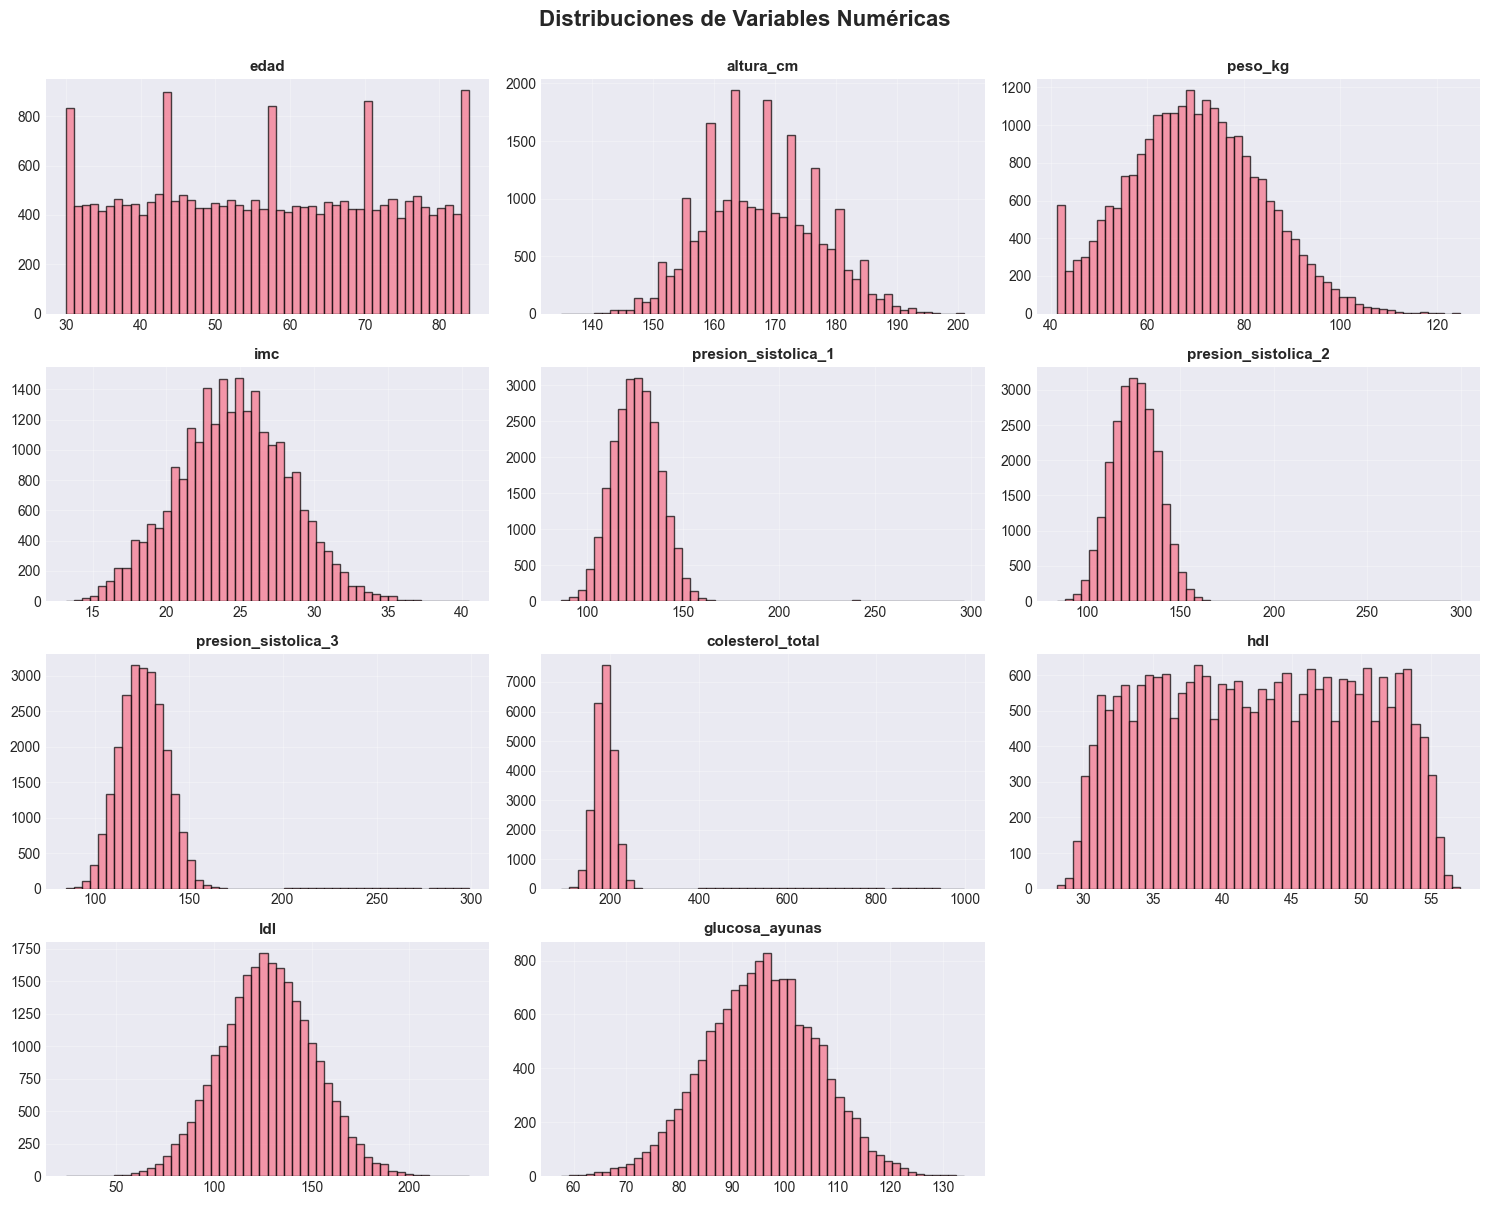

In [9]:
# Visualización de distribuciones
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(vars_numericas_continuas):
    # Histograma con KDE
    cardis_df_train[col].hist(bins=50, ax=axes[idx], alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].grid(alpha=0.3)

# Ocultar el último subplot si sobra
if len(vars_numericas_continuas) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('Distribuciones de Variables Numéricas', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

Como podemos ver gracias a estas visualizaciones, no parece que existan una gran cantidad de valores anómalos, por lo que podemos inferir que:
- Si que existen en variables como las presiones sistólicas, el colesterol o el IMC, pero muy probablemente correspondan a casos extremos pero reales, que es importante mantener pues son de vital importancia para nuestro sistema.
- Otras variables no parecen presentar valores anómalos, como la edad (que va de 30 a 84 años y solo tiene valores enteros), el peso (de 40 a 125 kilos, aproximadamente), o la glucosa (entre 60 y 130).

En resumen, estos datos parecen clínicamente posibles, incluso con la presencia de casos extremos, y coinciden con los de pacientes que tendría sentido que acudiesen a atención primaria.

<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 2. Distribución del target y desbalanceo

Una vez analizadas las variables con las que vamos a trabajar, es igual de importante analizar la variable objetivo, para ver si está balanceada, y de qué tipo es.

=== DISTRIBUCIÓN DE RIESGO_CV ===
riesgo_cv
0    18744
1     5256
Name: count, dtype: int64

Porcentajes:
riesgo_cv
0    78.1
1    21.9
Name: proportion, dtype: float64


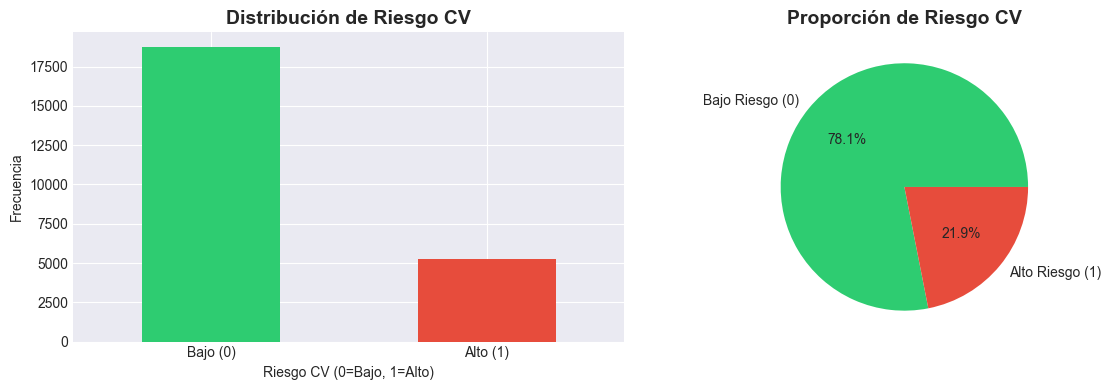

Ratio de desbalance: 3.57:1
Las clases están DESBALANCEADAS. Considerar técnicas de balanceo o usar métricas apropiadas (F1-Score).


In [10]:
# Distribución de la variable objetivo
print("=== DISTRIBUCIÓN DE RIESGO_CV ===")
print(cardis_df_train['riesgo_cv'].value_counts())
print("\nPorcentajes:")
print(cardis_df_train['riesgo_cv'].value_counts(normalize=True) * 100) # Con normalize, podemos ver porcentajes

# Visualización
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
cardis_df_train['riesgo_cv'].value_counts().plot(kind='bar', ax=ax[0], color=['#2ecc71', '#e74c3c'])
ax[0].set_title('Distribución de Riesgo CV', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Riesgo CV (0=Bajo, 1=Alto)')
ax[0].set_ylabel('Frecuencia')
ax[0].set_xticklabels(['Bajo (0)', 'Alto (1)'], rotation=0)

# Gráfico de pie
cardis_df_train['riesgo_cv'].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%', 
                                           colors=['#2ecc71', '#e74c3c'],
                                           labels=['Bajo Riesgo (0)', 'Alto Riesgo (1)'])
ax[1].set_title('Proporción de Riesgo CV', fontsize=14, fontweight='bold')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Calcular desbalance
counts = cardis_df_train['riesgo_cv'].value_counts()
ratio = counts.max() / counts.min()
print(f"Ratio de desbalance: {ratio:.2f}:1")
if ratio > 1.5:
    print("Las clases están DESBALANCEADAS. Considerar técnicas de balanceo o usar métricas apropiadas (F1-Score).")
else:
    print("Las clases están relativamente BALANCEADAS.")

Como podemos ver, la variable objetivo está notablemente desbalanceada. Esto tiene sentido en nuestro contexto, pues este efecto es clínicamente realista, ya que los pacientes, a rasgos generales, son más propensos a no tener un alto riesgo de sufrir una enfermedad cardiovascular que a tenerlo.

Sin embargo, no debemos pasar esto por alto, ya que podríamos obtener modelos con una alta _accuracy_ pero un _recall_ bajo, y eso significaría que tenemos un modelo que se "arriesga" poco, dando lugar a muchos falsos negativos, lo que es un problema en modelos clínicos. Por ello, es importante saber que métricas utilizar, como es el F1-Score en este caso como métrica principal; o la validación estratificada.

De la misma manera, el desbalanceo de estas clases también tiene implicaciones sobre la equidad, pues, si hay grupos infrarrepresentados en este conjunto de datos, este problema se amplifica de forma rápida.

<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 3. Valores ausentes: análisis y estrategia

Como se ha mencionado en apartados anteriores, existen variables que tienen valores ausentes. A continuación, se mostrarán estas variables y se indicará como se pueden resolver estas incongruencias en función de su carácter.

=== VALORES FALTANTES EN TRAIN ===
      Variable  Missing_Count  Missing_Pct
glucosa_ayunas          10394    43.308333
 notas_medicas           4833    20.137500
       fumador           2218     9.241667

Total de variables con missing: 3


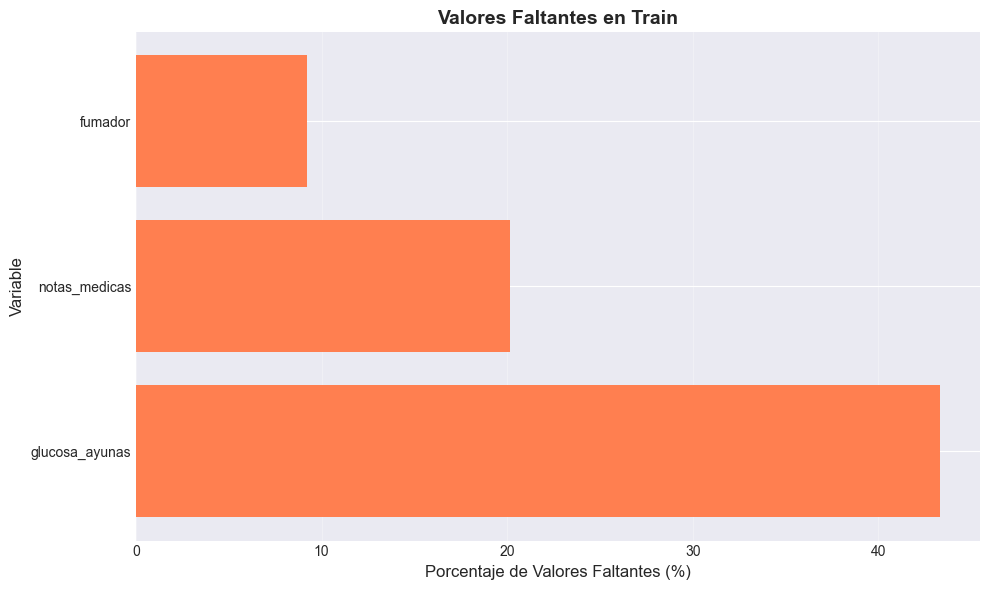

In [11]:
# Análisis de valores faltantes
def analizar_missing(df, nombre="Dataset"):
    """
    Analiza y visualiza los valores faltantes en un DataFrame.
    """
    print(f"=== VALORES FALTANTES EN {nombre.upper()} ===")
    
    # Calcular missing values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    
    # Crear DataFrame con resultados
    missing_df = pd.DataFrame({
        'Variable': missing.index,
        'Missing_Count': missing.values,
        'Missing_Pct': missing_pct.values
    })
    
    # Filtrar solo las que tienen missing
    missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
    
    if len(missing_df) == 0:
        print("✅ No hay valores faltantes en este dataset.")
        return missing_df
    
    print(missing_df.to_string(index=False))
    print(f"\nTotal de variables con missing: {len(missing_df)}")
    
    # Visualización
    if len(missing_df) > 0:
        plt.figure(figsize=(10, max(6, len(missing_df) * 0.3)))
        plt.barh(missing_df['Variable'], missing_df['Missing_Pct'], color='coral')
        plt.xlabel('Porcentaje de Valores Faltantes (%)', fontsize=12)
        plt.ylabel('Variable', fontsize=12)
        plt.title(f'Valores Faltantes en {nombre}', fontsize=14, fontweight='bold')
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    return missing_df

# Analizar train
missing_train = analizar_missing(cardis_df_train, "Train")

Como se puede ver, tenemos tres columnas con valores faltantes:
- **fumador**: con aproximadamente el 9% de valores perdidos, probablemente por que en muchos casos no se pregunte al paciente si es fumador habitual o no.
- **notas_medicas**: con en torno al 20% de valores perdidos, posiblemente por ausencia de hallazgos clínicos, aunque también podría indicar que no se registró sin motivo aparente.
- **glucosa_ayunas**: con aproximadamente el 45% de valores faltantes, lo que podría indicar que no a todos los pacientes se les hace una análitica, en caso de no ser necesario.

En cuanto a las estrategias que se pueden tomar para imputar estos valores desconocidos, recomendamos imputar por la moda o mediana en todos los casos, pero también evaluar si conviene añadir una categoría extra a las notas médicas que sea _desconocido_.

<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 4. Valores atípicos e inconsistencias

Otro punto importante a tratar son los valores atípicos o _outliers_, donde conviene distinguir de la forma más eficaz posible entre errores de medición, o valores extremos que pueden ser plausibles, aunque poco comunes.

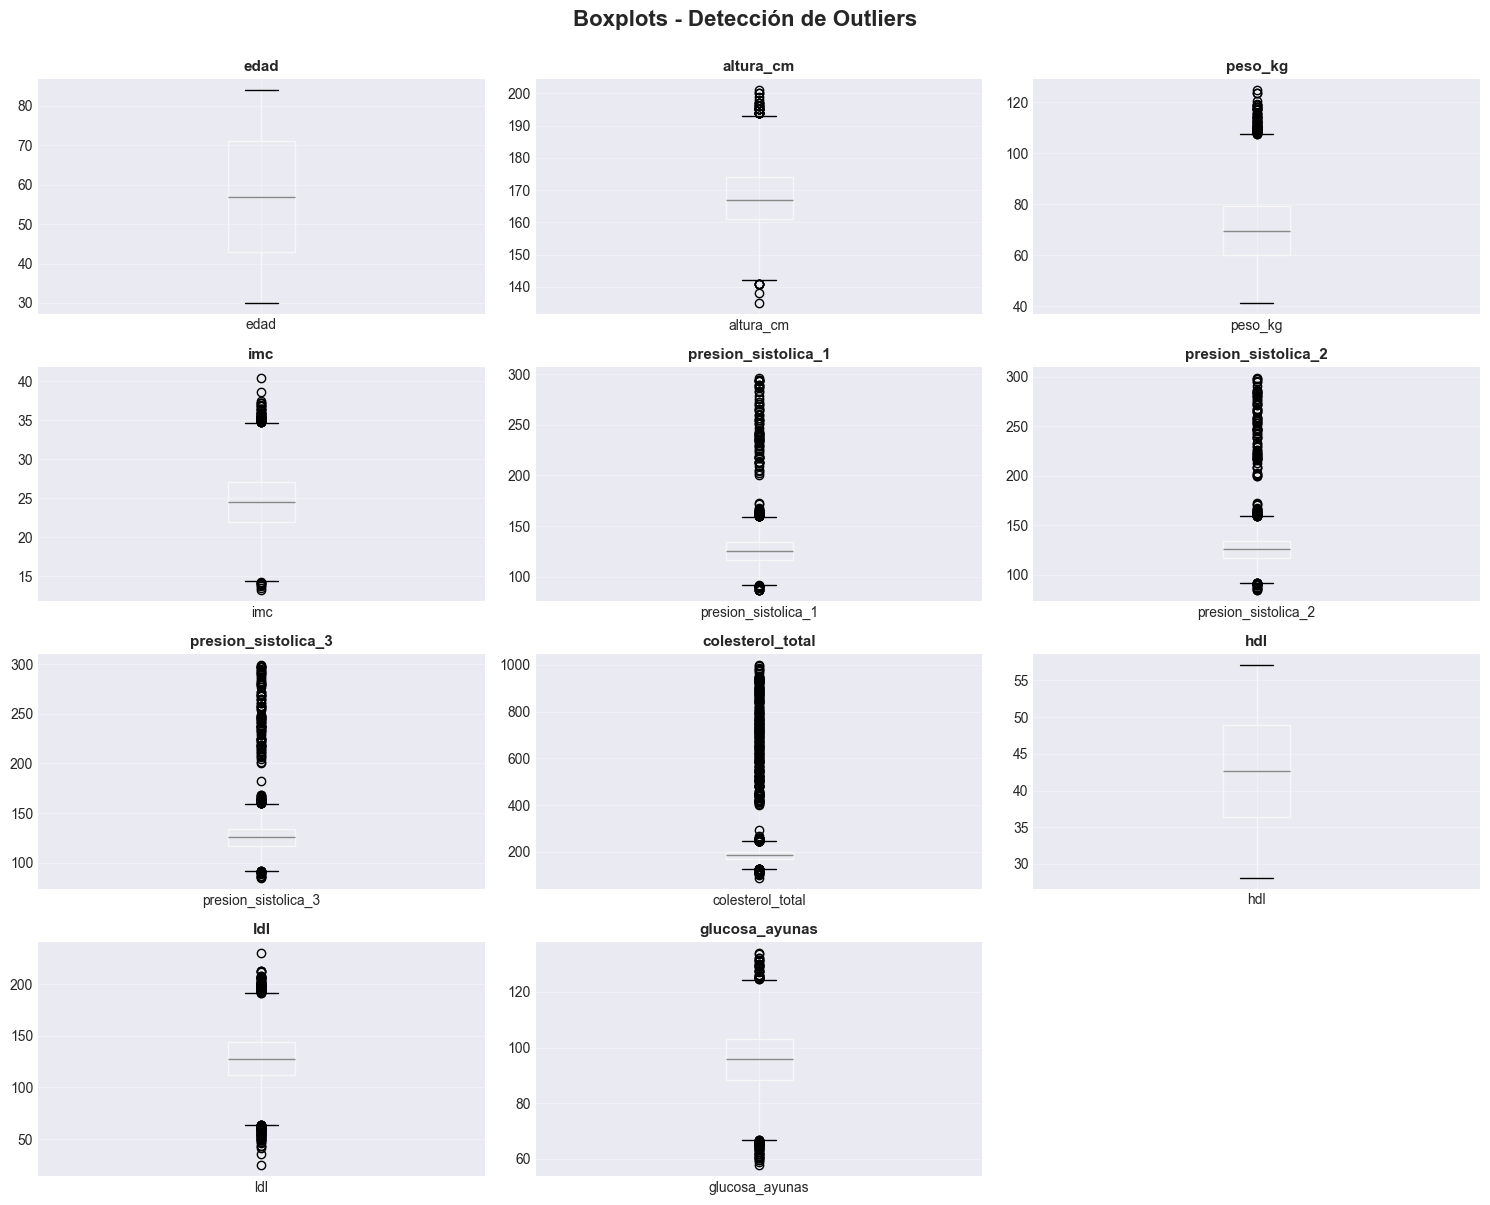

In [12]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(vars_numericas_continuas):
    cardis_df_train.boxplot(column=col, ax=axes[idx])
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('')
    axes[idx].grid(alpha=0.3)

# Ocultar el último subplot si sobra
if len(vars_numericas_continuas) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('Boxplots - Detección de Outliers', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

Como podemos ver, además del colesterol HDL y la edad, la mayoría de estas variables tienen _outliers_. Cuantifiquémoslos:

In [13]:
# Análisis cuantitativo de outliers usando IQR
def detectar_outliers_iqr(df, columnas):
    """
    Detecta outliers usando el método del rango intercuartílico (IQR).
    """
    outliers_info = []
    
    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        column_min = df[col].min()
        column_max = df[col].max()
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        n_outliers = len(outliers)
        pct_outliers = (n_outliers / len(df)) * 100
        
        outliers_info.append({
            'Variable': col,
            'N_Outliers': n_outliers,
            'Pct_Outliers': pct_outliers,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound,
            'Min': column_min,
            'Max': column_max
        })
    
    return pd.DataFrame(outliers_info).sort_values('Pct_Outliers', ascending=False)

print("=== OUTLIERS DETECTADOS (Método IQR) ===")
outliers_df = detectar_outliers_iqr(cardis_df_train, vars_numericas_continuas)
print(outliers_df.to_string(index=False))

=== OUTLIERS DETECTADOS (Método IQR) ===
           Variable  N_Outliers  Pct_Outliers  Lower_Bound  Upper_Bound   Min   Max
   colesterol_total         397      1.654167     126.1500     244.9500  89.1 999.8
                ldl         159      0.662500      63.8500     191.4500  24.6 230.5
presion_sistolica_2         157      0.654167      91.7500     159.3500  84.0 299.4
presion_sistolica_3         154      0.641667      91.6000     159.6000  84.7 299.2
presion_sistolica_1         134      0.558333      91.5000     159.5000  86.5 296.6
            peso_kg          87      0.362500      31.5625     107.6625  41.2 124.8
     glucosa_ayunas          84      0.350000      66.9000     124.5000  57.7 134.1
                imc          81      0.337500      14.3500      34.7500  13.2  40.5
          altura_cm          42      0.175000     141.5000     193.5000 135.0 201.0
               edad           0      0.000000       1.0000     113.0000  30.0  84.0
                hdl           0    

De acuerdo a los datos obtenidos, tan solo tenemos como máximo un 1.65% de valores atípicos en una columna, en este caso la de **colesterol_total**. El resto de columnas numéricas apenas llegan al 0.66% de _outliers_. En cuanto a si son errores de medición, es difícil de predecir, pues valores como el máximo de colesterol total en torno a 1000, aunque extremos, pueden ser posibles. En el resto de columnas tampoco se ven valores imposibles, por lo que mantendremos todos estos valores atípicos, pues pueden ser relevantes para el modelo.

<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 5. Correlaciones y relaciones

En este paso, analizaremos las correlaciones entre diferentes variables, que nos ayudarán a determinar cuales son aquellas más descriptivas para el modelo.

=== MATRIZ DE CORRELACIONES ===


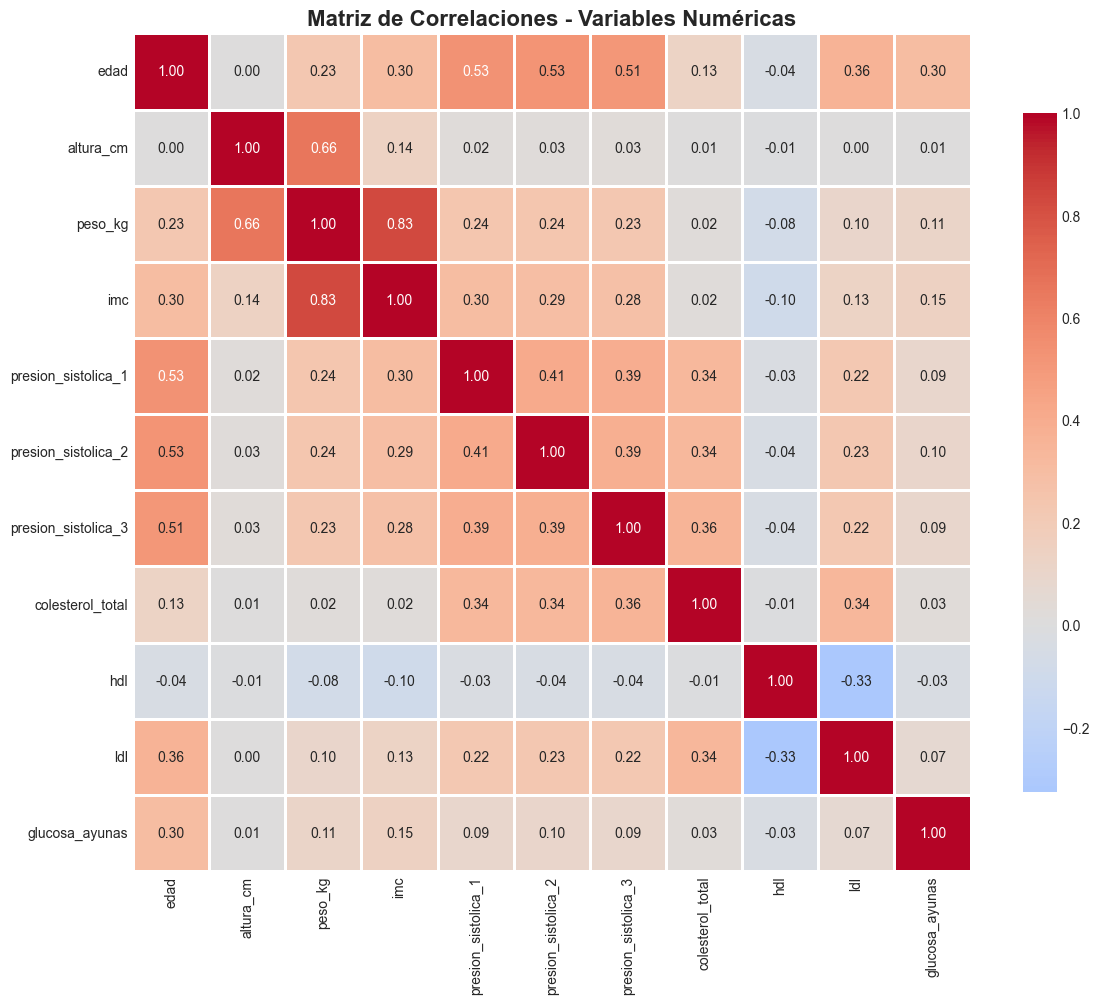


=== CORRELACIONES MÁS FUERTES (|r| > 0.7) ===
Variable_1 Variable_2  Correlación
   peso_kg        imc      0.83059


In [14]:
# Análisis de correlaciones entre variables numéricas
print("=== MATRIZ DE CORRELACIONES ===")

# Calcular correlaciones
correlaciones = cardis_df_train[vars_numericas_continuas].corr()

# Visualización
plt.figure(figsize=(12, 10))
sns.heatmap(correlaciones, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlaciones - Variables Numéricas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Identificar correlaciones altas (excluyendo la diagonal)
print("\n=== CORRELACIONES MÁS FUERTES (|r| > 0.7) ===")
correlaciones_altas = []
for i in range(len(correlaciones.columns)):
    for j in range(i+1, len(correlaciones.columns)):
        if abs(correlaciones.iloc[i, j]) > 0.7:
            correlaciones_altas.append({
                'Variable_1': correlaciones.columns[i],
                'Variable_2': correlaciones.columns[j],
                'Correlación': correlaciones.iloc[i, j]
            })

if correlaciones_altas:
    df_corr_altas = pd.DataFrame(correlaciones_altas).sort_values('Correlación', 
                                                                    key=abs, 
                                                                    ascending=False)
    print(df_corr_altas.to_string(index=False))
else:
    print("No se encontraron correlaciones superiores a 0.7")

Como podemos ver, la correlación más alta entre variables es entre el peso y el IMC, pues tiene sentido que una persona que pesa más, también tenga un IMC más elevado. En este caso, parece que la altura no está tan relacionada con el IMC como podría parecer en primera instancia. Por otra parte, el peso y la altura si parecen relacionadas.

Otras correlaciones a destacar ocurren entre las 3 presiones sistólicas, como cabría esperar; pero también entre ellas y la edad, indicando que personas más adultas tendrán una presión más elevada. Esto parece indicar que utilizar 3 mediciones de la presión no resulta útil del todo. En cuanto al colesterol, parece que el HDL y el LDL tienen una correlación inversa, algo que también parece intuitivo a priori.

A continuación, veremos la relación de estas variables con la variable objetivo:

=== CORRELACIONES CON RIESGO_CV ===
edad                   0.412331
ldl                    0.347480
presion_sistolica_2    0.326299
presion_sistolica_1    0.317846
presion_sistolica_3    0.308997
glucosa_ayunas         0.285772
imc                    0.208543
peso_kg                0.163090
colesterol_total       0.129014
altura_cm              0.009358
hdl                   -0.065157
Name: riesgo_cv, dtype: float64


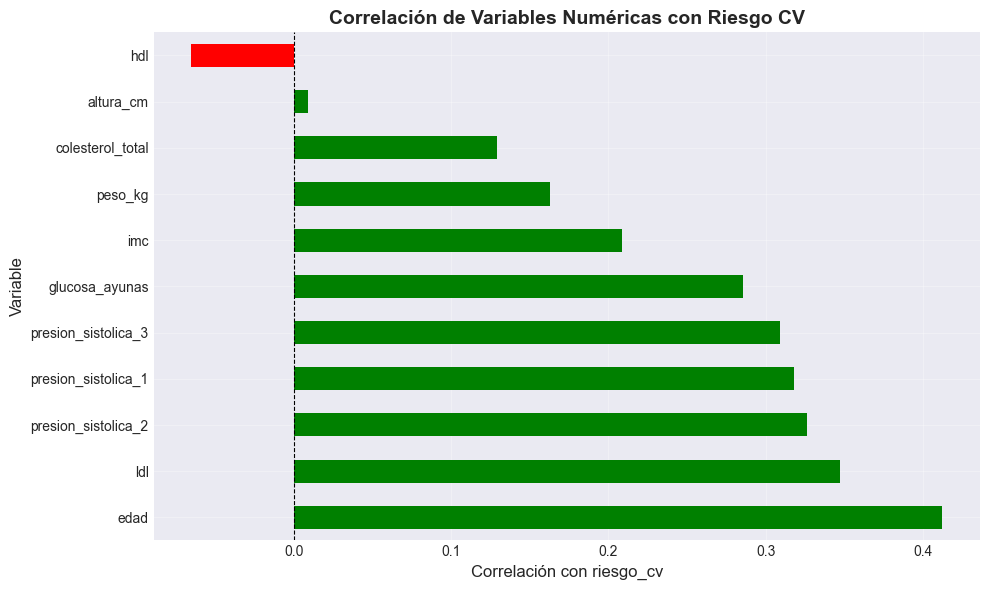


=== INTERPRETACIÓN ===
Correlaciones positivas: Mayor valor de la variable, mayor riesgo CV
Correlaciones negativas: Mayor valor de la variable, menor riesgo CV

Variables con correlación más fuerte (|r| > 0.1):
  - edad: 0.412
  - ldl: 0.347
  - presion_sistolica_2: 0.326
  - presion_sistolica_1: 0.318
  - presion_sistolica_3: 0.309
  - glucosa_ayunas: 0.286
  - imc: 0.209
  - peso_kg: 0.163
  - colesterol_total: 0.129


In [15]:
# Calcular correlaciones con riesgo_cv
print("=== CORRELACIONES CON RIESGO_CV ===")
correlaciones_target = cardis_df_train[vars_numericas_continuas + ['riesgo_cv']].corr()['riesgo_cv'].drop('riesgo_cv').sort_values(ascending=False)
print(correlaciones_target)

# Visualización
plt.figure(figsize=(10, 6))
correlaciones_target.plot(kind='barh', color=['green' if x > 0 else 'red' for x in correlaciones_target])
plt.xlabel('Correlación con riesgo_cv', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.title('Correlación de Variables Numéricas con Riesgo CV', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretación
print("\n=== INTERPRETACIÓN ===")
print("Correlaciones positivas: Mayor valor de la variable, mayor riesgo CV")
print("Correlaciones negativas: Mayor valor de la variable, menor riesgo CV")
print("\nVariables con correlación más fuerte (|r| > 0.1):")
vars_importantes = correlaciones_target[abs(correlaciones_target) > 0.1]
if len(vars_importantes) > 0:
    for var, corr in vars_importantes.items():
        print(f"  - {var}: {corr:.3f}")
else:
    print("  Ninguna variable tiene correlación > 0.1 con el target")

Basándonos en los datos anteriores, podemos afirmar que la edad es el predictor más fuerte ($r=0.41$), seguida del LDL ($r=0.35$) y las tres mediciones de presión sistólica ($r≈0.31-0.33$). La glucosa en ayunas, en cambio, muestra una correlación moderada ($r=0.29$), algo importante dado que tiene 45% de valores faltantes.

El HDL presenta correlación negativa muy débil ($r=-0.07$), menor de lo esperado clínicamente, lo que sugiere que su efecto protector podría manifestarse en interacciones con otras variables. El IMC y peso muestran correlaciones positivas moderadas ($r=0.21$ y $r=0.16$).

Las variables más predictivas de forma univariada son, en este orden: edad, colesterol LDL, presiones sistólicas y glucosa en ayunas.

<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 6. Variables de texto libre y categóricas de alta cardinalidad

En el siguiente paso, analizaremos las variables que nos quedan, que son, en este caso, las variables categóricas o de texto, que pueden tener una cardinalidad muy elevada en muchos casos y que conviene tratar. Primero, comenzaremos por las categóricas:

In [16]:
# Análisis de variables categóricas binarias
print("=== VARIABLES CATEGÓRICAS BINARIAS ===")

for var in vars_categoricas_binarias:
    print(f"\n--- {var.upper()} ---")
    print(cardis_df_train[var].value_counts())
    print("\nProporción:")
    print(cardis_df_train[var].value_counts(normalize=True) * 100)
    print("\nRelación con riesgo_cv:")
    print(pd.crosstab(cardis_df_train[var], cardis_df_train['riesgo_cv'], normalize='index') * 100)

=== VARIABLES CATEGÓRICAS BINARIAS ===

--- FUMADOR ---
fumador
0.0    16607
1.0     5175
Name: count, dtype: int64

Proporción:
fumador
0.0    76.241851
1.0    23.758149
Name: proportion, dtype: float64

Relación con riesgo_cv:
riesgo_cv          0          1
fumador                        
0.0        86.391281  13.608719
1.0        61.043478  38.956522

--- ANTECEDENTES_FAMILIARES ---
antecedentes_familiares
0    18171
1     5829
Name: count, dtype: int64

Proporción:
antecedentes_familiares
0    75.7125
1    24.2875
Name: proportion, dtype: float64

Relación con riesgo_cv:
riesgo_cv                        0          1
antecedentes_familiares                      
0                        80.078146  19.921854
1                        71.933436  28.066564


Como podemos ver, en primer lugar tenemos las variables relativas a los antecedentes familiares y el hábito tabáquico. Además, llama la atención que ser fumador tiene una relación alta con el riesgo de desarrollar enfermedades cardiovasculares, algo que no parece tan evidente con los antecedentes.

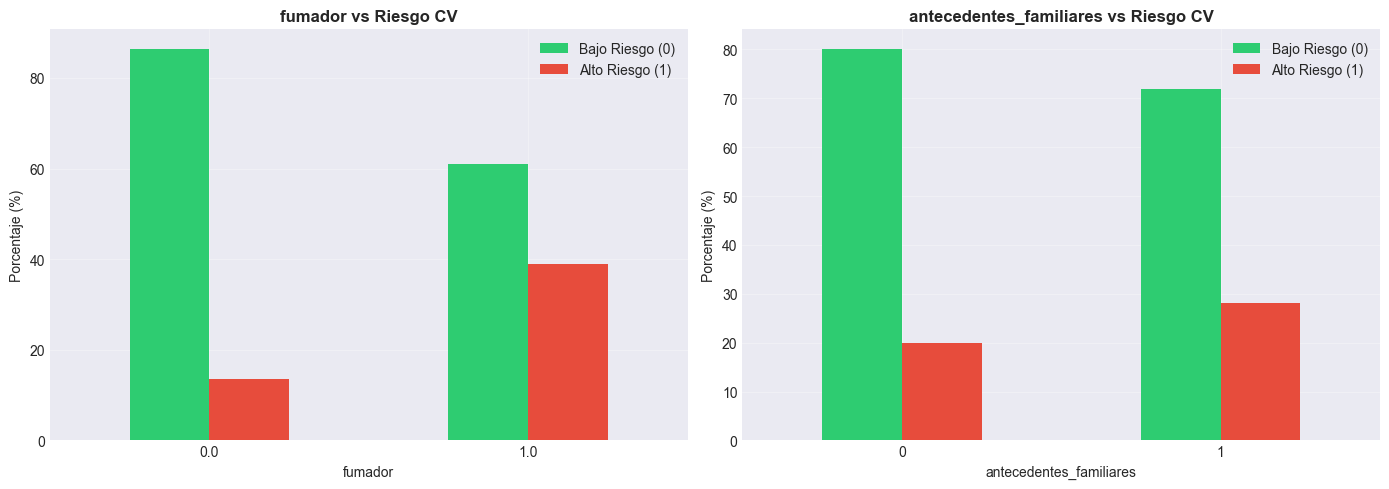

In [17]:
# Visualización de variables categóricas binarias vs target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, var in enumerate(vars_categoricas_binarias):
    ct = pd.crosstab(cardis_df_train[var], cardis_df_train['riesgo_cv'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[idx], color=['#2ecc71', '#e74c3c'])
    axes[idx].set_title(f'{var} vs Riesgo CV', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Porcentaje (%)')
    axes[idx].legend(['Bajo Riesgo (0)', 'Alto Riesgo (1)'])
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=0)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Este gráfico evidencia lo que se comentó anteriormente. Por otro lado, tenemos las variables categóricas no binarias o nominales:

=== ANÁLISIS DE CARDINALIDAD ===

--- HOSPITAL_ORIGEN ---
Valores únicos: 20

Top 10 más frecuentes:
hospital_origen
HOSP-005    1269
HOSP-002    1245
HOSP-007    1243
HOSP-012    1228
HOSP-009    1227
HOSP-015    1218
HOSP-016    1217
HOSP-018    1217
HOSP-017    1212
HOSP-014    1209
Name: count, dtype: int64

Entropía normalizada: 1.000
(0 = toda la masa en una categoría, 1 = distribución uniforme)

Recomendación de encoding:
  → Target Encoding o Feature Hashing (cardinalidad moderada)


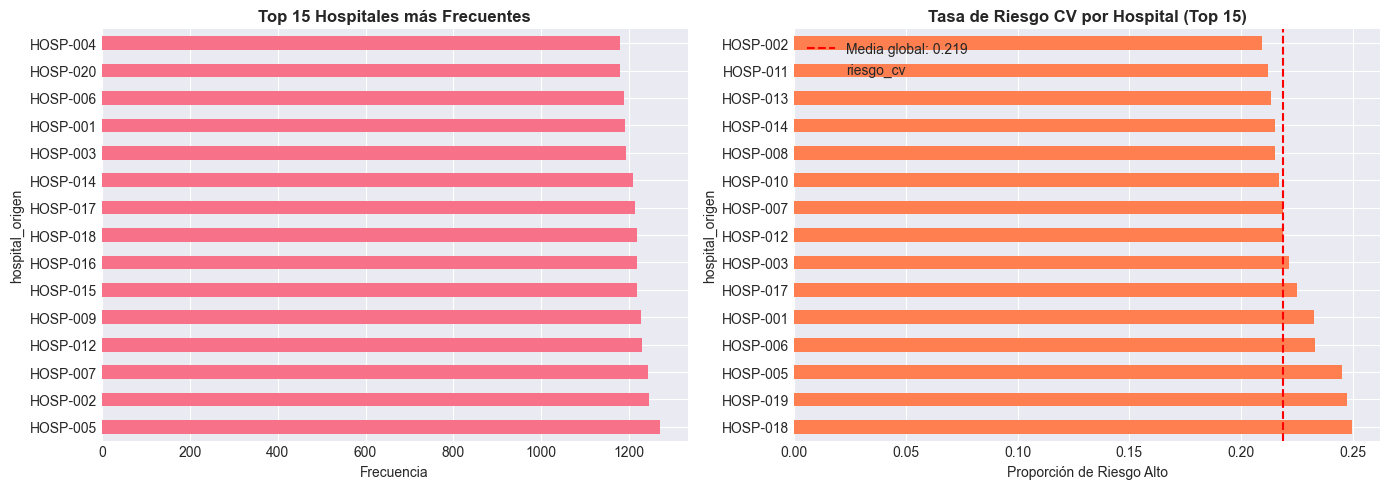


--- CODIGO_POSTAL ---
Valores únicos: 791

Top 10 más frecuentes:
codigo_postal
28022    68
38108    56
39010    50
36213    46
28523    44
50016    44
46009    44
7600     43
28943    43
4131     43
Name: count, dtype: int64

Entropía normalizada: 0.997
(0 = toda la masa en una categoría, 1 = distribución uniforme)

Recomendación de encoding:
  → Target Encoding, agrupar categorías, o eliminar (cardinalidad alta)


In [18]:
print("=== ANÁLISIS DE CARDINALIDAD ===")

for var in vars_categoricas_nominales:
    n_unique = cardis_df_train[var].nunique()
    print(f"\n--- {var.upper()} ---")
    print(f"Valores únicos: {n_unique}")
    
    # Mostrar top 10
    print("\nTop 10 más frecuentes:")
    print(cardis_df_train[var].value_counts().head(10))
    
    # Calcular entropía (medida de dispersión)
    value_counts = cardis_df_train[var].value_counts(normalize=True)
    entropy = -np.sum(value_counts * np.log2(value_counts))
    max_entropy = np.log2(n_unique)
    normalized_entropy = entropy / max_entropy if max_entropy > 0 else 0
    
    print(f"\nEntropía normalizada: {normalized_entropy:.3f}")
    print("(0 = toda la masa en una categoría, 1 = distribución uniforme)")
    
    # Recomendación de encoding
    print("\nRecomendación de encoding:")
    if n_unique <= 10:
        print("  → One-Hot Encoding (cardinalidad baja)")
    elif n_unique <= 50:
        print("  → Target Encoding o Feature Hashing (cardinalidad moderada)")
    else:
        print("  → Target Encoding, agrupar categorías, o eliminar (cardinalidad alta)")
    
    # Visualización para hospital_origen si cardinalidad es manejable
    if var == 'hospital_origen' and n_unique <= 30:
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))
        
        # Frecuencias
        cardis_df_train[var].value_counts().head(15).plot(kind='barh', ax=ax[0])
        ax[0].set_title(f'Top 15 Hospitales más Frecuentes', fontsize=12, fontweight='bold')
        ax[0].set_xlabel('Frecuencia')
        
        # Relación con target
        hospital_risk = cardis_df_train.groupby(var)['riesgo_cv'].mean().sort_values(ascending=False).head(15)
        hospital_risk.plot(kind='barh', ax=ax[1], color='coral')
        ax[1].set_title(f'Tasa de Riesgo CV por Hospital (Top 15)', fontsize=12, fontweight='bold')
        ax[1].set_xlabel('Proporción de Riesgo Alto')
        ax[1].axvline(x=cardis_df_train['riesgo_cv'].mean(), color='red', linestyle='--', 
                      label=f'Media global: {cardis_df_train["riesgo_cv"].mean():.3f}')
        ax[1].legend()
        
        plt.tight_layout()
        plt.show()

Por un lado, tenemos el hospital de origen, con una tasa de riesgo que va desde el 21% al 25%, lo que nos indica que el hospital donde se trata al paciente podría ser una cualidad informativa. Al tener tan solo 20 hospitales diferentes, se recomienda utilizar _Target Encoding_.

Por el otro, tenemos el código postal, con hasta 791 valores diferentes, donde el código postal mayoritario apenas supone el 0.3% del total del conjunto de datos. Por ello, recomendamos utilizar _Target Encoding_, agrupar por provincia, o directamente eliminar la columna.

Pasemos a analizar la componente temporal, la fecha de visita:

=== ANÁLISIS DE FECHA_VISITA ===
Componentes temporales extraídos: año, mes, dia_semana, hora

Rango de fechas en train: 2017-10-18 18:47:44.789084 a 2022-08-09 03:42:18.789084
Rango de fechas en test: 2022-08-09 04:27:13.789084 a 2025-10-16 16:51:12.789084

--- Distribución por año ---
año
2017    1027
2018    5056
2019    4986
2020    4924
2021    5057
2022    2950
Name: count, dtype: int64

--- Distribución por mes ---
mes
1     2174
2     1942
3     2098
4     2027
5     2190
6     2020
7     2151
8     1813
9     1633
10    1782
11    2040
12    2130
Name: count, dtype: int64

--- Distribución por día de la semana ---
Lunes: 3438
Martes: 3347
Miércoles: 3374
Jueves: 3376
Viernes: 3590
Sábado: 3433
Domingo: 3442


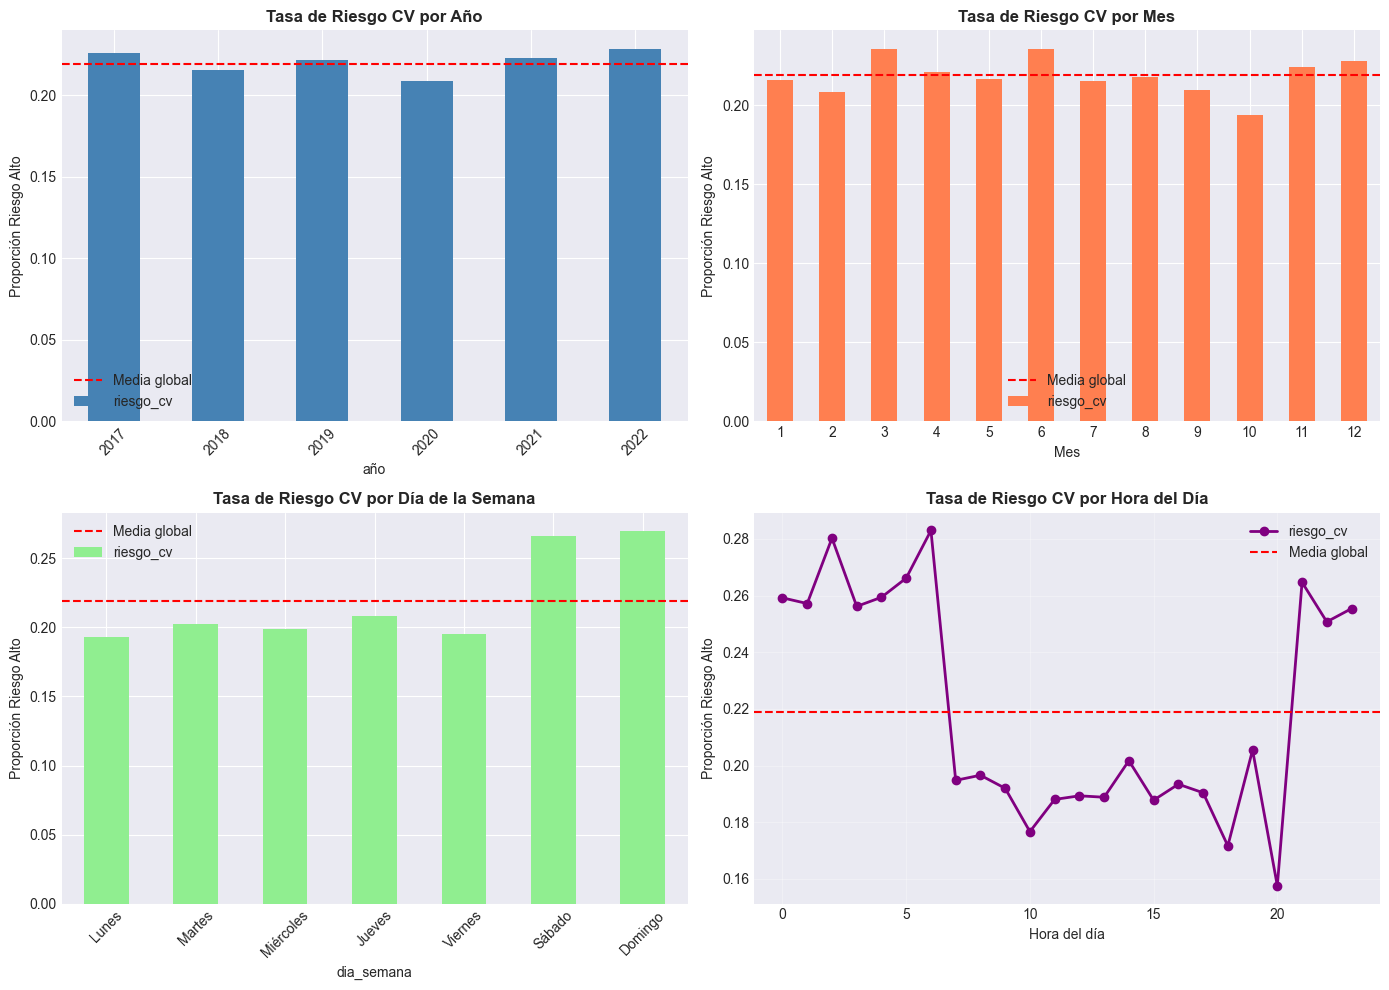

In [19]:
## Análisis de Variable Temporal - fecha_visita
print("=== ANÁLISIS DE FECHA_VISITA ===")

# Convertir a datetime
cardis_df_train['fecha_visita'] = pd.to_datetime(cardis_df_train['fecha_visita'])
cardis_df_test['fecha_visita'] = pd.to_datetime(cardis_df_test['fecha_visita'])

# Extraer componentes temporales
cardis_df_train['año'] = cardis_df_train['fecha_visita'].dt.year
cardis_df_train['mes'] = cardis_df_train['fecha_visita'].dt.month
cardis_df_train['dia_semana'] = cardis_df_train['fecha_visita'].dt.dayofweek  # 0=Lunes, 6=Domingo
cardis_df_train['hora'] = cardis_df_train['fecha_visita'].dt.hour

# Lo mismo para test
cardis_df_test['año'] = cardis_df_test['fecha_visita'].dt.year
cardis_df_test['mes'] = cardis_df_test['fecha_visita'].dt.month
cardis_df_test['dia_semana'] = cardis_df_test['fecha_visita'].dt.dayofweek
cardis_df_test['hora'] = cardis_df_test['fecha_visita'].dt.hour

print("Componentes temporales extraídos: año, mes, dia_semana, hora")

# Análisis de rangos
print(f"\nRango de fechas en train: {cardis_df_train['fecha_visita'].min()} a {cardis_df_train['fecha_visita'].max()}")
print(f"Rango de fechas en test: {cardis_df_test['fecha_visita'].min()} a {cardis_df_test['fecha_visita'].max()}")

# Distribuciones
print("\n--- Distribución por año ---")
print(cardis_df_train['año'].value_counts().sort_index())

print("\n--- Distribución por mes ---")
print(cardis_df_train['mes'].value_counts().sort_index())

print("\n--- Distribución por día de la semana ---")
dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
dia_counts = cardis_df_train['dia_semana'].value_counts().sort_index()
for i, count in dia_counts.items():
    print(f"{dias[i]}: {count}")

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Por año
cardis_df_train.groupby('año')['riesgo_cv'].mean().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Tasa de Riesgo CV por Año', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Proporción Riesgo Alto')
axes[0,0].axhline(y=cardis_df_train['riesgo_cv'].mean(), color='red', linestyle='--', label='Media global')
axes[0,0].legend()
axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=45)

# Por mes
cardis_df_train.groupby('mes')['riesgo_cv'].mean().plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Tasa de Riesgo CV por Mes', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Proporción Riesgo Alto')
axes[0,1].axhline(y=cardis_df_train['riesgo_cv'].mean(), color='red', linestyle='--', label='Media global')
axes[0,1].legend()
axes[0,1].set_xlabel('Mes')
axes[0,1].set_xticklabels(range(1,13), rotation=0)

# Por día de semana
dia_risk = cardis_df_train.groupby('dia_semana')['riesgo_cv'].mean()
dia_risk.plot(kind='bar', ax=axes[1,0], color='lightgreen')
axes[1,0].set_title('Tasa de Riesgo CV por Día de la Semana', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Proporción Riesgo Alto')
axes[1,0].axhline(y=cardis_df_train['riesgo_cv'].mean(), color='red', linestyle='--', label='Media global')
axes[1,0].legend()
axes[1,0].set_xticklabels(dias, rotation=45)

# Por hora
cardis_df_train.groupby('hora')['riesgo_cv'].mean().plot(kind='line', ax=axes[1,1], 
                                                   marker='o', color='purple', linewidth=2)
axes[1,1].set_title('Tasa de Riesgo CV por Hora del Día', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Proporción Riesgo Alto')
axes[1,1].axhline(y=cardis_df_train['riesgo_cv'].mean(), color='red', linestyle='--', label='Media global')
axes[1,1].legend()
axes[1,1].set_xlabel('Hora del día')
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Analizando la distribución temporal de los datos desde 2017 hasta 2022, observamos que la tasa de riesgo cardiovascular se mantiene notablemente estable entre años, sin cambios significativos. Esto descarta deriva temporal importante y sugiere estabilidad en protocolos médicos y características de la población atendida.

La variación mensual es menos notable, destacando octubre con una tasa ligeramente inferior (~19%) frente a la media del 22%. El resto de meses muestra variaciones mínimas alrededor de la media global.

El patrón por día de semana revela diferencias importantes: los fines de semana (sábado y domingo) presentan tasas de riesgo sustancialmente superiores (~27%) comparadas con los días laborables (~19-21%). Este patrón sugiere que las visitas de fin de semana corresponden predominantemente a casos urgentes o más graves.

El análisis por hora del día muestra el patrón más pronunciado: las horas nocturnas y de madrugada (especialmente 4-5h y 21-22h) alcanzan tasas superiores al 26-28%, mientras que las horas centrales del día presentan tasas mínimas alrededor del 17-19%. Esta clara diferenciación indica que las visitas nocturnas son principalmente urgencias cardiovasculares, mientras que las diurnas incluyen mayor proporción de consultas programadas.

Esto nos lleva a pensar que la componente temporal podría ser de utilidad para el sistema.

A continuación, analicemos la actividad física de los pacientes:

=== ANÁLISIS DE ACTIVIDAD_FISICA ===
Ejemplos de valores en actividad_fisica:
0     ~0.4 horas
1     ~2.6 horas
2     ~3.7 horas
3           poco
4     ~0.0 horas
5      2,2 horas
6     ~1.6 horas
7     ~3.4 horas
8     ~3.2 horas
9           0.7h
10    ~1.7 horas
11    ~0.1 horas
12    ~0.0 horas
13    ~2.8 horas
14     2,2 horas
15    ~2.8 horas
16    ~9.3 horas
17    ~0.3 horas
18    ~0.0 horas
19          0.2h
Name: actividad_fisica, dtype: str

Estadísticas de horas de actividad física:
count    19235.000000
mean         2.242251
std          2.304417
min          0.000000
25%          0.500000
50%          1.500000
75%          3.200000
max         10.000000
Name: horas_actividad_fisica, dtype: float64

Valores faltantes:
Antes de parsear: 0 (0.00%)
Después de parsear: 4765 (19.85%)


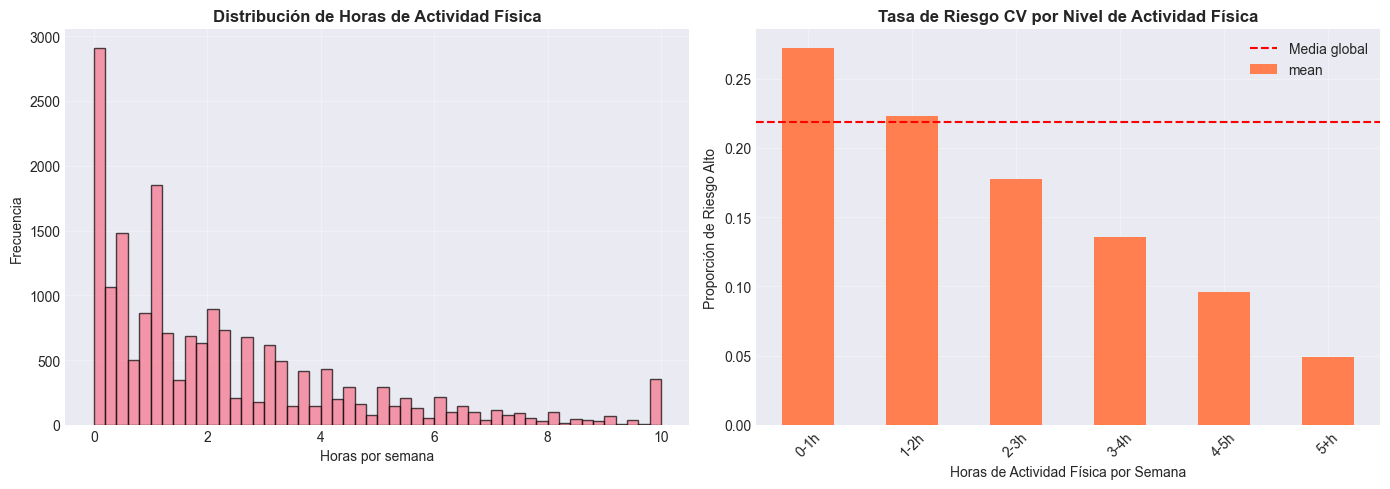


--- Riesgo CV por nivel de actividad ---
                    mean  count
actividad_bins                 
0-1h            0.271974   5552
1-2h            0.223379   3841
2-3h            0.177236   2460
3-4h            0.135752   1709
4-5h            0.095916   1053
5+h             0.048791   2316

Correlación horas_actividad_fisica con riesgo_cv: -0.225


In [20]:
## Análisis de actividad_fisica
print("=== ANÁLISIS DE ACTIVIDAD_FISICA ===")

# Ver ejemplos de valores
print("Ejemplos de valores en actividad_fisica:")
print(cardis_df_train['actividad_fisica'].head(20))

# Función para extraer horas de actividad física
def extraer_horas_actividad(texto):
    """
    Extrae el valor numérico de horas de strings como '~2.5 horas'
    Retorna NaN si el texto es NaN o no se puede parsear
    """
    if pd.isna(texto):
        return np.nan
    
    try:
        # Buscar patrón numérico (puede tener punto decimal)
        import re
        match = re.search(r'(\d+\.?\d*)', str(texto))
        if match:
            return float(match.group(1))
        else:
            return np.nan
    except:
        return np.nan

# Aplicar extracción
cardis_df_train['horas_actividad_fisica'] = cardis_df_train['actividad_fisica'].apply(extraer_horas_actividad)
cardis_df_test['horas_actividad_fisica'] = cardis_df_test['actividad_fisica'].apply(extraer_horas_actividad)

print("\nEstadísticas de horas de actividad física:")
print(cardis_df_train['horas_actividad_fisica'].describe())

print("\nValores faltantes:")
print(f"Antes de parsear: {cardis_df_train['actividad_fisica'].isna().sum()} ({cardis_df_train['actividad_fisica'].isna().sum()/len(cardis_df_train)*100:.2f}%)")
print(f"Después de parsear: {cardis_df_train['horas_actividad_fisica'].isna().sum()} ({cardis_df_train['horas_actividad_fisica'].isna().sum()/len(cardis_df_train)*100:.2f}%)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de horas
cardis_df_train['horas_actividad_fisica'].hist(bins=50, ax=axes[0], edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución de Horas de Actividad Física', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Horas por semana')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(alpha=0.3)

# Relación con riesgo_cv
# Crear bins para agrupar
cardis_df_train['actividad_bins'] = pd.cut(cardis_df_train['horas_actividad_fisica'], 
                                     bins=[0, 1, 2, 3, 4, 5, 20], 
                                     labels=['0-1h', '1-2h', '2-3h', '3-4h', '4-5h', '5+h'])

risk_by_activity = cardis_df_train.groupby('actividad_bins', observed=True)['riesgo_cv'].agg(['mean', 'count'])
risk_by_activity['mean'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Tasa de Riesgo CV por Nivel de Actividad Física', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Horas de Actividad Física por Semana')
axes[1].set_ylabel('Proporción de Riesgo Alto')
axes[1].axhline(y=cardis_df_train['riesgo_cv'].mean(), color='red', linestyle='--', label='Media global')
axes[1].legend()
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n--- Riesgo CV por nivel de actividad ---")
print(risk_by_activity)

# Correlación con target
corr_actividad = cardis_df_train[['horas_actividad_fisica', 'riesgo_cv']].corr().iloc[0, 1]
print(f"\nCorrelación horas_actividad_fisica con riesgo_cv: {corr_actividad:.3f}")

# Eliminar columna auxiliar
cardis_df_train.drop('actividad_bins', axis=1, inplace=True)

El parseo de la variable actividad_fisica revela un problema importante: aunque no hay valores faltantes en el campo original (0%), el parseo numérico genera un 19.85% de valores no extraíbles. Esto se debe a la heterogeneidad en el formato de entrada, incluyendo textos como "poco", "0.7h" con diferentes notaciones, o comas en lugar de puntos decimales.

La distribución de horas de actividad física muestra un patrón fuertemente concentrado en valores bajos, como cabría esperar: la mayoría de pacientes reporta entre 0-2 horas semanales, con un pico muy pronunciado cerca de 0 horas. La distribución presenta una cola larga hacia la derecha, con algunos casos extremos reportando hasta 10 horas semanales.

El análisis de riesgo cardiovascular por nivel de actividad física confirma claramente el efecto protector del ejercicio. Los pacientes sedentarios (0-1h) presentan la tasa de riesgo más alta (~27%), muy superior a la media global del 22%. A medida que aumentan las horas de actividad, el riesgo disminuye progresivamente: 1-2h (~22%), 2-3h (~18%), 3-4h (~14%), 4-5h (~10%), y el grupo más activo (5+h) muestra un riesgo de apenas ~5%. Esta relación inversa clara y casi lineal confirma que la actividad física es un factor protector muy relevante.

La correlación con la variable objetivo es negativa, confirmando que mayor actividad física se asocia con menor riesgo cardiovascular. Esta variable, una vez correctamente parseada e imputada, será probablemente muy predictiva en los modelos.

Por último, analicemos las notas médicas:

=== ANÁLISIS DE NOTAS_MEDICAS ===
Ejemplos de notas médicas:

1. El paciente tiene periodos de actividad seguidos de inactividad....

2. EXPLORACIÓN FÍSICA COMPLETAMENTE NORMAL, SIN NINGÚN HALLAZGO PATOLÓGICO....

3. No se añaden nuevos diagnósticos al historial clínico....

4. paciente con alta probabilidad de padecer síndrome metabólico....

5. Antecedentes Familiares De Infarto De Miocardio En Edad Temprana (Padre < 55 Años)....

6. Ecg Dentro De Los Límites De La Normalidad, Ritmo Sinusal Estable....

7. [SIN NOTA]

8. Paciente Normopeso Con Un Imc Óptimo....

9. [SIN NOTA]

10. Reporta Ser Fumador Desde Hace Muchos Años....

Pacientes con notas: 19167 (79.9%)
Pacientes sin notas: 4833 (20.1%)

Estadísticas de longitud (solo notas existentes):
count    19167.000000
mean        54.477122
std         12.436506
min         16.000000
25%         46.000000
50%         54.000000
75%         61.000000
max        124.000000
Name: longitud_notas, dtype: float64

ANÁLISIS DE PALABRAS CLAVE P

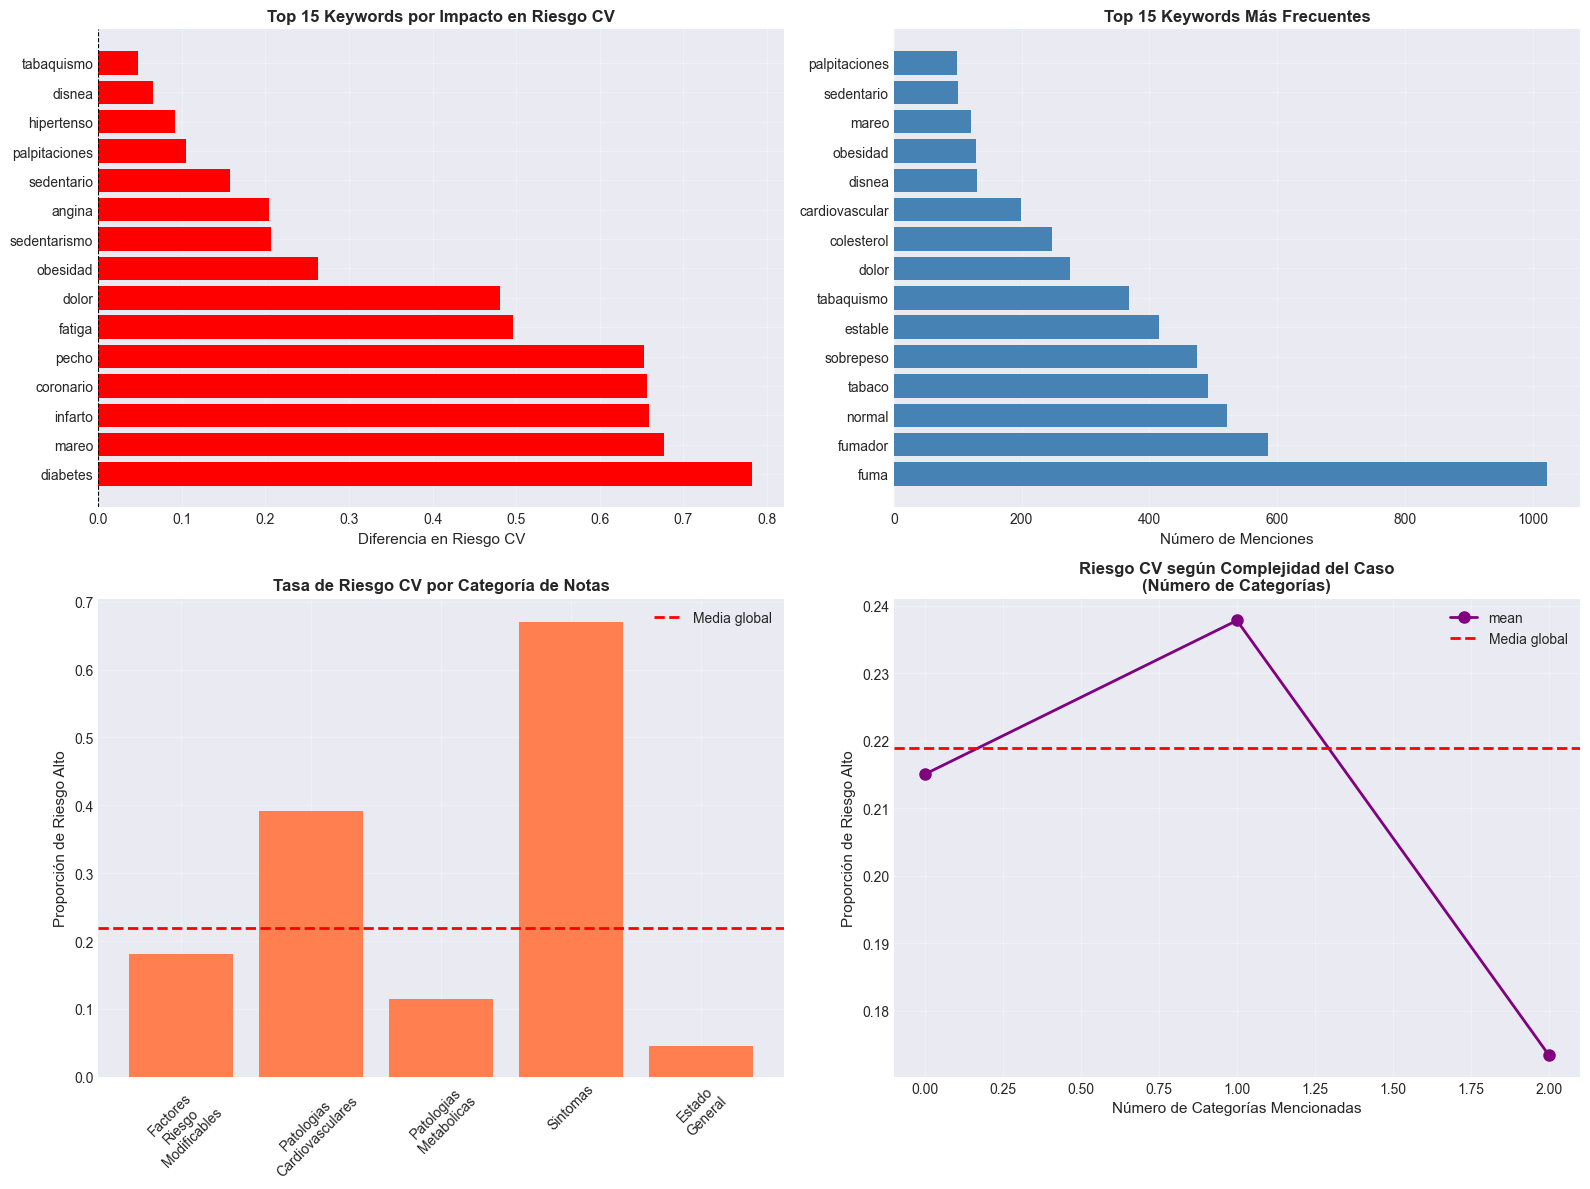

In [21]:
## Análisis de notas_medicas (Texto Libre)
print("=== ANÁLISIS DE NOTAS_MEDICAS ===")

# Ver ejemplos de notas
print("Ejemplos de notas médicas:")
for i in range(10):
    nota = cardis_df_train.loc[i, 'notas_medicas']
    if pd.notna(nota):
        print(f"\n{i+1}. {nota[:250]}...")
    else:
        print(f"\n{i+1}. [SIN NOTA]")

# Estadísticas básicas
n_con_notas = cardis_df_train['notas_medicas'].notna().sum()
n_sin_notas = cardis_df_train['notas_medicas'].isna().sum()
print(f"\n{'='*60}")
print(f"Pacientes con notas: {n_con_notas} ({n_con_notas/len(cardis_df_train)*100:.1f}%)")
print(f"Pacientes sin notas: {n_sin_notas} ({n_sin_notas/len(cardis_df_train)*100:.1f}%)")

# Extraer longitud de las notas
cardis_df_train['longitud_notas'] = cardis_df_train['notas_medicas'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
cardis_df_test['longitud_notas'] = cardis_df_test['notas_medicas'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)

print("\nEstadísticas de longitud (solo notas existentes):")
print(cardis_df_train[cardis_df_train['longitud_notas'] > 0]['longitud_notas'].describe())

# Análisis de palabras clave por CATEGORÍAS
print(f"\n{'='*60}")
print("ANÁLISIS DE PALABRAS CLAVE POR CATEGORÍAS")
print(f"{'='*60}")

# Definir categorías de keywords
categorias_keywords = {
    'Factores_Riesgo_Modificables': ['fumador', 'fuma', 'tabaco', 'tabaquismo', 'sedentario', 
                                      'sedentarismo', 'sobrepeso', 'obesidad', 'obeso'],
    'Patologias_Cardiovasculares': ['hipertension', 'hipertenso', 'cardiaco', 'cardiovascular', 
                                     'coronario', 'infarto', 'angina'],
    'Patologias_Metabolicas': ['diabetes', 'diabetico', 'glucosa', 'hiperglucemia', 
                                'colesterol', 'dislipemia', 'trigliceridos'],
    'Sintomas': ['dolor', 'pecho', 'torax', 'disnea', 'fatiga', 'mareo', 'palpitaciones'],
    'Estado_General': ['normal', 'estable', 'controlado', 'asintomatico']
}

# Crear variables binarias para cada keyword
resultados_keywords = []

for categoria, keywords in categorias_keywords.items():
    print(f"\n--- {categoria.replace('_', ' ').upper()} ---")
    
    for keyword in keywords:
        # Buscar keyword (case insensitive)
        col_name = f'nota_{keyword}'
        cardis_df_train[col_name] = cardis_df_train['notas_medicas'].fillna('').str.lower().str.contains(keyword).astype(int)
        cardis_df_test[col_name] = cardis_df_test['notas_medicas'].fillna('').str.lower().str.contains(keyword).astype(int)
        
        n_menciones = cardis_df_train[col_name].sum()
        
        if n_menciones > 0:
            # Calcular porcentaje sobre total de pacientes (no solo los que tienen notas)
            pct_total = (n_menciones / len(cardis_df_train)) * 100
            # Calcular porcentaje sobre pacientes con notas
            pct_con_notas = (n_menciones / n_con_notas) * 100
            # Riesgo promedio en pacientes con esta keyword
            riesgo_con_keyword = cardis_df_train[cardis_df_train[col_name] == 1]['riesgo_cv'].mean()
            # Riesgo promedio en pacientes sin esta keyword
            riesgo_sin_keyword = cardis_df_train[cardis_df_train[col_name] == 0]['riesgo_cv'].mean()
            
            resultados_keywords.append({
                'Categoria': categoria,
                'Keyword': keyword,
                'N_Menciones': n_menciones,
                'Pct_Total': pct_total,
                'Pct_Con_Notas': pct_con_notas,
                'Riesgo_Con': riesgo_con_keyword,
                'Riesgo_Sin': riesgo_sin_keyword,
                'Diferencia_Riesgo': riesgo_con_keyword - riesgo_sin_keyword
            })
            
            print(f"  {keyword:20s}: {n_menciones:4d} menciones ({pct_total:4.1f}% total, "
                  f"{pct_con_notas:5.1f}% con notas) | Riesgo: {riesgo_con_keyword:.3f} "
                  f"(Δ={riesgo_con_keyword - riesgo_sin_keyword:+.3f})")

# Crear DataFrame con resultados
df_keywords = pd.DataFrame(resultados_keywords)

# Ordenar por diferencia de riesgo (mayor impacto)
print(f"\n{'='*60}")
print("TOP 10 KEYWORDS CON MAYOR IMPACTO EN RIESGO CV")
print(f"{'='*60}")
top_keywords = df_keywords.nlargest(10, 'Diferencia_Riesgo')
print(top_keywords[['Keyword', 'N_Menciones', 'Riesgo_Con', 'Diferencia_Riesgo']].to_string(index=False))

# Crear variables agregadas por categoría
print(f"\n{'='*60}")
print("VARIABLES AGREGADAS POR CATEGORÍA")
print(f"{'='*60}")

for categoria, keywords in categorias_keywords.items():
    # Crear columna que indica si el paciente tiene al menos una keyword de esta categoría
    col_name = f'categoria_{categoria.lower()}'
    columnas_keywords = [f'nota_{kw}' for kw in keywords if f'nota_{kw}' in cardis_df_train.columns]
    
    cardis_df_train[col_name] = cardis_df_train[columnas_keywords].max(axis=1)
    cardis_df_test[col_name] = cardis_df_test[columnas_keywords].max(axis=1)
    
    n_pacientes = cardis_df_train[col_name].sum()
    pct = (n_pacientes / len(cardis_df_train)) * 100
    riesgo = cardis_df_train[cardis_df_train[col_name] == 1]['riesgo_cv'].mean()
    
    print(f"{categoria:30s}: {n_pacientes:5d} pacientes ({pct:5.1f}%) | Riesgo: {riesgo:.3f}")

# Análisis de combinaciones de categorías
print(f"\n{'='*60}")
print("ANÁLISIS DE COMBINACIONES DE FACTORES")
print(f"{'='*60}")

# Contar número total de categorías mencionadas por paciente
cols_categorias = [f'categoria_{cat.lower()}' for cat in categorias_keywords.keys()]
cardis_df_train['n_categorias_mencionadas'] = cardis_df_train[cols_categorias].sum(axis=1)

print("\nDistribución de número de categorías mencionadas por paciente:")
print(cardis_df_train['n_categorias_mencionadas'].value_counts().sort_index())

print("\nRiesgo CV según número de categorías mencionadas:")
risk_by_n_cat = cardis_df_train.groupby('n_categorias_mencionadas')['riesgo_cv'].agg(['mean', 'count'])
print(risk_by_n_cat)

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top keywords por impacto en riesgo
top_15 = df_keywords.nlargest(15, 'Diferencia_Riesgo')
axes[0, 0].barh(top_15['Keyword'], top_15['Diferencia_Riesgo'], 
                color=['red' if x > 0 else 'green' for x in top_15['Diferencia_Riesgo']])
axes[0, 0].set_xlabel('Diferencia en Riesgo CV', fontsize=11)
axes[0, 0].set_title('Top 15 Keywords por Impacto en Riesgo CV', fontsize=12, fontweight='bold')
axes[0, 0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[0, 0].grid(alpha=0.3)

# 2. Frecuencia de keywords más comunes
top_freq = df_keywords.nlargest(15, 'N_Menciones')
axes[0, 1].barh(top_freq['Keyword'], top_freq['N_Menciones'], color='steelblue')
axes[0, 1].set_xlabel('Número de Menciones', fontsize=11)
axes[0, 1].set_title('Top 15 Keywords Más Frecuentes', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# 3. Riesgo por categoría
cat_risk = []
cat_names = []
for categoria in categorias_keywords.keys():
    col_name = f'categoria_{categoria.lower()}'
    riesgo = cardis_df_train[cardis_df_train[col_name] == 1]['riesgo_cv'].mean()
    cat_risk.append(riesgo)
    cat_names.append(categoria.replace('_', '\n'))

axes[1, 0].bar(cat_names, cat_risk, color='coral')
axes[1, 0].axhline(y=cardis_df_train['riesgo_cv'].mean(), color='red', linestyle='--', 
                   linewidth=2, label='Media global')
axes[1, 0].set_ylabel('Proporción de Riesgo Alto', fontsize=11)
axes[1, 0].set_title('Tasa de Riesgo CV por Categoría de Notas', fontsize=12, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Riesgo según número de categorías mencionadas
risk_by_n_cat['mean'].plot(kind='line', ax=axes[1, 1], marker='o', 
                           linewidth=2, markersize=8, color='purple')
axes[1, 1].axhline(y=cardis_df_train['riesgo_cv'].mean(), color='red', linestyle='--', 
                   linewidth=2, label='Media global')
axes[1, 1].set_xlabel('Número de Categorías Mencionadas', fontsize=11)
axes[1, 1].set_ylabel('Proporción de Riesgo Alto', fontsize=11)
axes[1, 1].set_title('Riesgo CV según Complejidad del Caso\n(Número de Categorías)', 
                     fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

El análisis de las notas médicas revela información clínica valiosa a través de la extracción estructurada de keywords o palabras clave. Aproximadamente el 80% de los pacientes tienen notas médicas registradas.

**Keywords con mayor impacto en riesgo cardiovascular:**

Las keywords que más incrementan el riesgo son patologías y síntomas graves. "Diabetes" lidera con una diferencia de +0.78 en la tasa de riesgo: pacientes con diabetes mencionada tienen tasas cercanas al 100% de riesgo alto, frente al 22% global. Le siguen "mareo" (+0.60), "infarto" (+0.58) y "coronario" (+0.53), todas indicadoras de patología cardiovascular establecida o eventos agudos. 

Los síntomas como "pecho" (+0.48), "fatiga" (+0.44) y "dolor" (+0.35) también incrementan significativamente el riesgo, sugiriendo que la documentación de sintomatología cardiovascular específica es fuertemente predictiva. El "sedentarismo" (+0.24) y "angina" (+0.19) completan el grupo de keywords con impacto elevado.

**Keywords más frecuentes:**

Las menciones más comunes son "fuma/fumador" (~1000 menciones), "normal" (~550), "tabaco/tabaquismo" (~450), "sobrepeso" (~420) y "estable" (~400). Curiosamente, muchas de las keywords más frecuentes no son las de mayor impacto, lo que sugiere que términos comunes como "normal" o "estable" aparecen en pacientes de bajo riesgo, mientras que términos menos frecuentes pero más específicos (diabetes, infarto) son altamente discriminativos.

**Análisis por categorías:**

Las categorías de síntomas (dolor, pecho, disnea) y patologías cardiovasculares muestran tasas de riesgo extremadamente altas (~67%), triplicando la media global. Las patologías metabólicas (diabetes, colesterol) también presentan riesgo elevado (~39%). Sorprendentemente, las menciones de estado general (normal, estable) se asocian con riesgo muy bajo (~4%), confirmando que son indicadores de pacientes sanos. Los factores de riesgo modificables (fumador, sedentario, obesidad) muestran riesgo intermedio (~18%), ligeramente inferior a la media global.

**Complejidad del caso:**

El número de categorías mencionadas por paciente refleja la complejidad clínica. La mayoría de pacientes (19,292, ~80%) no tiene ninguna categoría mencionada o tiene notas genéricas, con riesgo del 21.5%. Los pacientes con una categoría mencionada (4,512 casos) muestran riesgo elevado del 23.8%. Curiosamente, los 196 pacientes con dos categorías mencionadas presentan riesgo inferior (17.3%), posiblemente porque incluyen menciones de factores protectores o seguimiento controlado.

**Resumen y recomendaciones:**

Variables extraídas de notas_medicas para el modelado:
- longitud_notas: longitud en caracteres
- n_categorias_mencionadas: indicador de complejidad del caso
- Indicadores binarios de keywords individuales
- Indicadores agregados por categoría (5 categorías)

Keywords más predictivas (mayor diferencia de riesgo):
- diabetes: Δ riesgo = +0.78
- mareo: Δ riesgo = +0.60
- infarto: Δ riesgo = +0.58
- coronario: Δ riesgo = +0.53
- pecho: Δ riesgo = +0.48

Se recomienda usar las variables agregadas por categoría para reducir dimensionalidad y evitar sobreajuste, complementadas con las top keywords individuales más discriminativas.

<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 7. Análisis de sesgos poblaciones y equidad

<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 8. Conclusiones y estrategia propuesta

Finalmente, podemos hacer un resumen detallado del análisis que se ha hecho para este conjunto de datos.

**Sobre la variable objetivo:**
El dataset presenta un desbalance de clases significativo (78% bajo riesgo vs 22% alto riesgo), lo que justifica el uso de F1-Score como métrica de evaluación y requiere estrategias específicas durante el modelado (validación estratificada, posible ajuste de pesos de clase).

**Variables más predictivas identificadas:**
- **Edad** ($r=0.41$): El predictor univariado más fuerte, coherente con el conocimiento clínico.
- **LDL** ($r=0.35$): El colesterol "malo" muestra alta correlación con el riesgo.
- **Presiones sistólicas** ($r≈0.31-0.33$): Las tres mediciones son informativas, aunque presentan variabilidad entre ellas.
- **Glucosa en ayunas** ($r=0.29$): Relevante, pero con 45% de valores faltantes que requerirán tratamiento especial.
- **Horas de actividad física**: Relación inversa muy clara con el riesgo (efecto protector).
- **Keywords de notas médicas**: "Diabetes", "infarto", "coronario" y síntomas cardiovasculares son altamente discriminativos.

**Patrones temporales relevantes:**
Las visitas en fines de semana y horario nocturno/madrugada presentan tasas de riesgo significativamente superiores, sugiriendo que capturan casos de urgencia cardiovascular. Las variables del día de la semana y la hora serán predictoras valiosas.

**Variables problemáticas:**
- **glucosa_ayunas**: 45% de valores faltantes requiere estrategia cuidadosa.
- **codigo_postal**: 791 valores únicos hacen inviable One-Hot Encoding.
- **actividad_fisica**: Formatos heterogéneos generan ~20% de valores no parseables.
- **talla_zapato**: Sin relación clínica ni estadística relevante con el target.

**Colinealidad detectada:**
La correlación peso_kg-imc ($r=0.83$) es la única que supera 0.7. Las tres presiones sistólicas presentan correlaciones moderadas entre sí (r≈0.4), menor de lo esperado, indicando variabilidad en las mediciones.

---

Una vez analizado el EDA, se propone la siguiente estrategia de preprocesamiento para el notebook de modelado:

### Variables a eliminar:
- **id**: Identificador sin valor predictivo.
- **talla_zapato**: Sin correlación relevante con el target ni sentido clínico.
- **fecha_visita**: Se elimina tras extraer componentes temporales.
- **notas_medicas**: Se elimina tras extraer keywords y categorías.
- **actividad_fisica**: Se elimina tras parsear las horas.

### Tratamiento de valores faltantes:
- **glucosa_ayunas (45%)**: Imputar con la mediana estratificada por grupo de edad, o crear variable binaria indicando si la prueba se realizó. Evaluar ambas estrategias.
- **fumador (8%)**: Imputar con la moda (valor más frecuente).
- **horas_actividad_fisica (20%)**: Imputar con la mediana o crear categoría "desconocido".

### Encoding de variables categóricas:
- **fumador, antecedentes_familiares**: Mantener como 0/1 (ya son binarias).
- **hospital_origen (20 valores)**: Target Encoding, dado que muestra variabilidad en tasas de riesgo.
- **codigo_postal (791 valores)**: Target Encoding o agrupar por provincia (primeros 2 dígitos), o eliminar si no aporta valor.

### Ingeniería de características:
- **Presiones sistólicas**: Crear media, mediana y desviación estándar de las 3 mediciones. Evaluar si reemplazar las originales o complementarlas.
- **Fecha**: Conservar año, mes, día de la semana y hora como variables numéricas o categóricas según el modelo.
- **Notas médicas**: Incluir indicadores de categorías (5 variables) y las top keywords individuales más predictivas.
- **Actividad física**: Usar las horas de actividad física como variable numérica continua.

### Escalado:
Aplicar _StandardScaler_ o _RobustScaler_ (más resistente a outliers) a las variables numéricas, especialmente para modelos sensibles a la escala (regresión logística, k-NN, SVM, etc).

### Tratamiento de outliers:
Las presiones sistólicas 2 y 3 presentan valores extremos clínicamente improbables, pero posibles. Se conservarán, pues pueden ser infomativos para el modelo.